In [1]:
import pandas as pd

file_path = r"C:\Users\branglin\Downloads\archive\7817_1.csv"

df = pd.read_csv(file_path)

print(df.head())


                     id       asins   brand                  categories  \
0  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
1  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
2  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
3  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
4  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   

  colors             dateAdded           dateUpdated  \
0    NaN  2016-03-08T20:21:53Z  2017-07-18T23:52:58Z   
1    NaN  2016-03-08T20:21:53Z  2017-07-18T23:52:58Z   
2    NaN  2016-03-08T20:21:53Z  2017-07-18T23:52:58Z   
3    NaN  2016-03-08T20:21:53Z  2017-07-18T23:52:58Z   
4    NaN  2016-03-08T20:21:53Z  2017-07-18T23:52:58Z   

                  dimension  ean                         keys  ...  \
0  169 mm x 117 mm x 9.1 mm  NaN  kindlepaperwhite/b00qjdu3ky  ...   
1  169 mm x 117 mm x 9.1 mm  NaN  kindlepaperwhite/b00qjdu3ky  ...   
2 

# Amazon Product Reviews Analysis

## CodeAlpha Data Analytics Internship Project

### Objective
The objective of this project is to analyze Amazon product reviews using Exploratory Data Analysis (EDA), Data Visualization, and Sentiment Analysis.

In [2]:
print(df.shape)

(1597, 27)


# Exploratory Data Analysis (EDA)

This section explores the dataset structure, missing values, ratings, brands, and customer recommendations.

In [3]:
print(df.columns)

Index(['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded',
       'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer',
       'manufacturerNumber', 'name', 'prices', 'reviews.date',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes',
       'upc', 'weight'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  reviews.doRecommend  

In [5]:
df['reviews.rating'].describe()

count    1177.000000
mean        4.359388
std         1.021445
min         1.000000
25%         4.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: reviews.rating, dtype: float64

In [6]:
df['reviews.rating'].value_counts()

reviews.rating
5.0    741
4.0    236
3.0    124
1.0     42
2.0     34
Name: count, dtype: int64

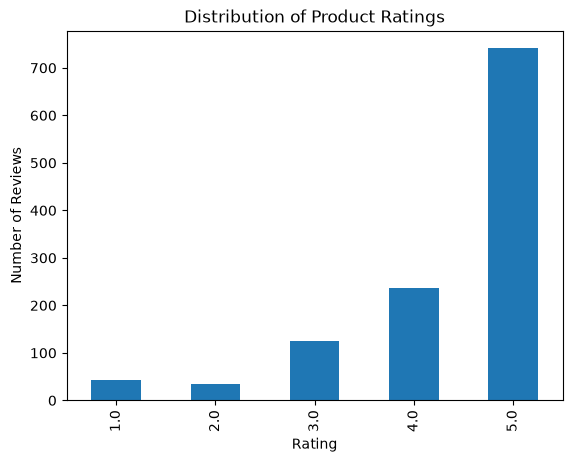

In [7]:
import matplotlib.pyplot as plt

df['reviews.rating'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

# Data Visualization

This section uses charts and graphs to identify patterns in customer ratings, recommendations, and sentiments.

In [8]:
df['brand'].value_counts().head(10)

brand
Amazon    1585
Moshi       12
Name: count, dtype: int64

In [9]:
df['reviews.doRecommend'].value_counts()

reviews.doRecommend
True     503
False     36
Name: count, dtype: int64

In [10]:
df['reviews.rating'].mean()

np.float64(4.3593882752761255)

In [11]:
df.isnull().sum()

id                         0
asins                      0
brand                      0
categories                 0
colors                   823
dateAdded                  0
dateUpdated                0
dimension               1032
ean                      699
keys                       0
manufacturer             632
manufacturerNumber       695
name                       0
prices                     0
reviews.date             380
reviews.doRecommend     1058
reviews.numHelpful       697
reviews.rating           420
reviews.sourceURLs         0
reviews.text               0
reviews.title             17
reviews.userCity        1597
reviews.userProvince    1597
reviews.username          17
sizes                   1597
upc                      699
weight                   911
dtype: int64

In [12]:
from textblob import TextBlob

# Sentiment Analysis

This section analyzes customer reviews using TextBlob and classifies them into Positive, Negative, and Neutral sentiments.

In [13]:
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

df['sentiment_score'] = df['reviews.text'].apply(get_sentiment)

df[['reviews.text', 'sentiment_score']].head()

,reviews.text,sentiment_score
0,I initially had trouble deciding between the p...,0.200259
1,Allow me to preface this with a little history...,0.159591
2,I am enjoying it so far. Great for reading. Ha...,0.420833
3,I bought one of the first Paperwhites and have...,0.148821
4,I have to say upfront - I don't like coroporat...,0.267086


In [14]:
def sentiment_label(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(sentiment_label)

df['sentiment'].value_counts()

sentiment
Positive    1479
Negative      77
Neutral       41
Name: count, dtype: int64

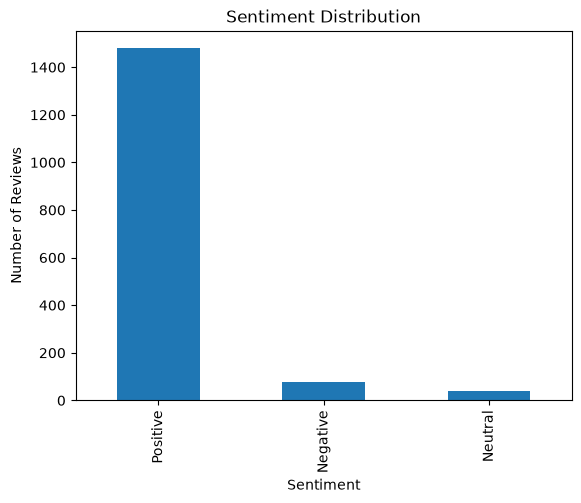

In [15]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

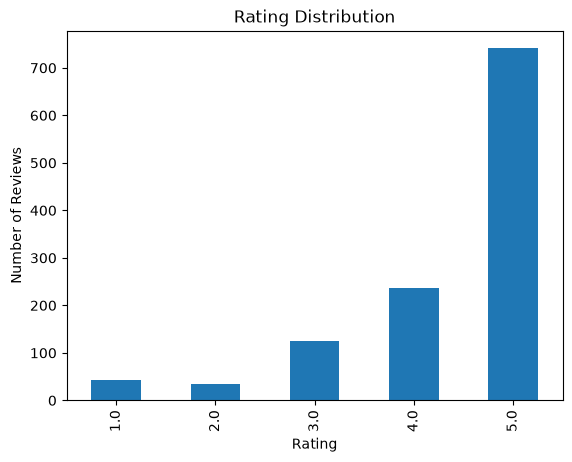

In [16]:
df['reviews.rating'].value_counts().sort_index().plot(kind='bar')

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

# Conclusion

This project analyzed Amazon product reviews using Exploratory Data Analysis (EDA), Data Visualization, and Sentiment Analysis.

## Key Findings

- Average product rating: 4.36/5
- Most reviews are 5-star ratings.
- Positive reviews dominate the dataset.
- Most customers recommend the products.

## Final Insight

The analysis shows that customers are highly satisfied with Amazon products, as reflected in both ratings and sentiment scores.